## FEM in 2-D: Poisson's Equation

Implement an FEM code that solves Poisson's equation
$$ -\nabla^2 u(x,y) = 1 \quad \text{in} \quad \Omega = (0,1)\times(0,1)$$ 
using linear triangular elements. The boundary conditions are homogeneous Dirichlet ($u=0$) for the coincides with lines $x=0$ and $y=0$ and homogeneous Neumann (${\bf{n}}\cdot \nabla u = 0$) for the rest. Apply numerical integration to compute the stiffness matrices.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.spatial import Delaunay
from matplotlib.path import Path

In [3]:
def unique_rows(a, tol=12):
    a_rounded = np.round(a, decimals=tol)
    _, idx = np.unique(a_rounded, axis=0, return_index=True)
    idx = np.sort(idx)
    return a[idx]


def triangle_area(p1, p2, p3):
    return 0.5 * (
        p1[0] * (p2[1] - p3[1]) +
        p2[0] * (p3[1] - p1[1]) +
        p3[0] * (p1[1] - p2[1])
    )


def circumcenter(p1, p2, p3):
    K = np.array([
        [2 * (p1[0] - p2[0]), 2 * (p1[1] - p2[1])],
        [2 * (p2[0] - p3[0]), 2 * (p2[1] - p3[1])]
    ], dtype=float)

    F = np.array([
        p1[0]**2 - p2[0]**2 + p1[1]**2 - p2[1]**2,
        p2[0]**2 - p3[0]**2 + p2[1]**2 - p3[1]**2
    ], dtype=float)

    detK = np.linalg.det(K)
    if abs(detK) < 1e-14:
        return np.mean(np.vstack([p1, p2, p3]), axis=0)

    return np.linalg.solve(K, F)


def centroids(points, tri):
    return np.mean(points[tri], axis=1)


def delaunay_tri(points):
    return Delaunay(points).simplices.copy()


def inpolygon_points(points, poly):
    path = Path(poly)
    inside = path.contains_points(points)

    on = np.zeros(len(points), dtype=bool)
    tol = 1e-10

    for i in range(len(poly) - 1):
        a = poly[i]
        b = poly[i + 1]
        ab = b - a
        ab2 = np.dot(ab, ab)
        if ab2 < 1e-14:
            continue

        ap = points - a
        t = np.sum(ap * ab, axis=1) / ab2
        t = np.clip(t, 0.0, 1.0)
        proj = a + np.outer(t, ab)
        dist = np.linalg.norm(points - proj, axis=1)
        on |= dist < tol

    return inside | on, on

In [4]:
def pmesh(pv, hmax, nref):
    pv = np.array(pv, dtype=float)

    edge = len(pv) - 1

    for i in range(edge):
        d = np.linalg.norm(pv[i + 1] - pv[i])
        if hmax < d:
            n = int(np.ceil(d / hmax))
            nx = np.linspace(pv[i, 0], pv[i + 1, 0], n + 1)
            ny = np.linspace(pv[i, 1], pv[i + 1, 1], n + 1)

            if len(nx) > 2:
                new_pts = np.column_stack([nx[1:-1], ny[1:-1]])
                pv = np.vstack([pv, new_pts])

    poly = pv[:edge + 1].copy()
    pv = unique_rows(pv)

    while True:
        tri = delaunay_tri(pv)

        A = np.zeros(len(tri))
        C = np.zeros((len(tri), 2))
        D = np.zeros((len(tri), 2))

        for i, tri_nodes in enumerate(tri):
            p1, p2, p3 = pv[tri_nodes]
            A[i] = abs(triangle_area(p1, p2, p3))
            C[i] = circumcenter(p1, p2, p3)
            D[i] = np.mean([p1, p2, p3], axis=0)

        inside, _ = inpolygon_points(D, poly)
        tri = tri[inside]
        A = A[inside]
        C = C[inside]

        if len(A) == 0:
            break

        if np.max(A) < (hmax**2) / 2:
            break
        else:
            ind = np.argmax(A)
            pv = np.vstack([pv, C[ind]])
            pv = unique_rows(pv)

    for _ in range(nref):
        tri = delaunay_tri(pv)

        mids = []
        for tri_nodes in tri:
            p1, p2, p3 = pv[tri_nodes]
            mids.append(0.5 * (p1 + p2))
            mids.append(0.5 * (p1 + p3))
            mids.append(0.5 * (p2 + p3))

        if mids:
            pv = np.vstack([pv, np.array(mids)])

        pv = unique_rows(pv)
        tri = delaunay_tri(pv)

        AA = np.zeros(len(tri))
        DD = np.zeros((len(tri), 2))

        for l, tri_nodes in enumerate(tri):
            p1, p2, p3 = pv[tri_nodes]
            AA[l] = triangle_area(p1, p2, p3)
            DD[l] = np.mean([p1, p2, p3], axis=0)

        keep = np.abs(AA) > 0.0
        tri = tri[keep]
        AA = AA[keep]
        DD = DD[keep]

        tiny = np.abs(AA) < hmax**2 / 1e12
        if np.any(tiny):
            extra_pts = DD[tiny]
            pv = np.vstack([pv, extra_pts])
            pv = unique_rows(pv)

        tri = delaunay_tri(pv)

        DD = centroids(pv, tri)
        inside, _ = inpolygon_points(DD, poly)
        tri = tri[inside]

    p = pv.copy()
    t = tri.copy()

    _, on = inpolygon_points(p, poly)
    e = np.where(on)[0]

    return p, t, e

In [5]:
def gauss2D_tri(ngp):
    if ngp == 1:
        wgp = np.array([0.5])
        xgp = np.array([1/3.,1/3.])
    elif ngp == 3:
        wgp = np.array([1/6.,1/6.,1/6.])
        xgp = np.array([0.5, 0.5],[0,0.5],[0.5,0])
    else:
        print("Number of Gauss Points specified not supported")
    #
    return wgp, xgp

In [6]:
def Nlocal2D_tri(p,x):
    if p == 1:
        N = np.array([x[0],x[1],1-x[0]-x[1]])
        Nx = np.array([[1.0,0.0,-1.0],[0.0,1.0,-1.0]])
    else:
        print("Basis function order specified not supported")
    #
    return N, Nx

In [7]:
# NUMERICAL INTEGRATION
ngp = 1 #Number of Gaussian Quadrature Points
p = 1 #Element Order
wgp, xgp = gauss2D_tri(ngp)
Ng, Nxg = Nlocal2D_tri(p,xgp)

In [8]:
Nxg

array([[ 1.,  0., -1.],
       [ 0.,  1., -1.]])

In [29]:
#-----------
# MAIN CODE
#-----------
# Define the domain to be meshed:
pv1 = np.array([[0, 0],[1, 0],[1, 1],[0, 1],[0, 0]], dtype=float)
# Mesh:
nodes, conn, b_nodes = pmesh(pv1, 0.1, 0)

In [31]:
nodes

array([[0.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 1.        ],
       [0.        , 1.        ],
       [0.1       , 0.        ],
       [0.2       , 0.        ],
       [0.3       , 0.        ],
       [0.4       , 0.        ],
       [0.5       , 0.        ],
       [0.6       , 0.        ],
       [0.7       , 0.        ],
       [0.8       , 0.        ],
       [0.9       , 0.        ],
       [1.        , 0.1       ],
       [1.        , 0.2       ],
       [1.        , 0.3       ],
       [1.        , 0.4       ],
       [1.        , 0.5       ],
       [1.        , 0.6       ],
       [1.        , 0.7       ],
       [1.        , 0.8       ],
       [1.        , 0.9       ],
       [0.9       , 1.        ],
       [0.8       , 1.        ],
       [0.7       , 1.        ],
       [0.6       , 1.        ],
       [0.5       , 1.        ],
       [0.4       , 1.        ],
       [0.3       , 1.        ],
       [0.2       , 1.        ],
       [0.

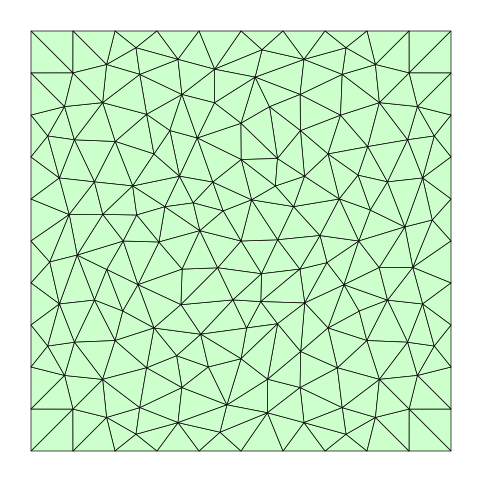

In [33]:
# Visualize the assigned mesh:
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
#
fig, ax = plt.subplots(figsize=(6, 6))
#
verts = [nodes[elem] for elem in conn]
#
pc = PolyCollection(
    verts,
    facecolors=[(0.8, 1.0, 0.8)],
    edgecolors='k',
    linewidths=0.5)
#
ax.add_collection(pc)
ax.autoscale()
ax.set_aspect('equal')
ax.set_axis_off()
#
plt.show()

In [35]:
# FEM Assembly
nn = len(nodes)
ne = len(conn)
#
K = np.zeros((nn, nn))
F = np.zeros(nn)
#
for elem in range(ne):
    lm = conn[elem, :]
    ln = nodes[lm, :]
    for gp in range(0,ngp):
        J = np.array([[ln[0,0]-ln[2,0],ln[0,1]-ln[2,1]],
                      [ln[1,0]-ln[2,0],ln[1,1]-ln[2,1]]]) 
        #
        B = np.linalg.solve(J,Nxg)
        detJ = np.linalg.det(J)
        #
        ke = (B.T @ B)*detJ*wgp[gp]
        fe = Ng*detJ*wgp[gp]
        # Assembly
        K[np.ix_(lm, lm)] += ke
        F[lm] += fe

In [37]:
#-------------------------------------
# Apply boundary conditions and solve
#-------------------------------------

# Dirichlet boundary nodes: x=0 or y=0
nd = np.where((nodes[:, 0] < 1e-6) | (nodes[:, 1] < 1e-6))[0]

# Active DOFs
n_active = np.setdiff1d(np.arange(nn), nd)
#
K_reduced = K[np.ix_(n_active, n_active)]
F_reduced = F[n_active]
# Solve
u = np.linalg.solve(K_reduced, F_reduced)
#
u_sol = np.zeros(nn)
u_sol[n_active] = u

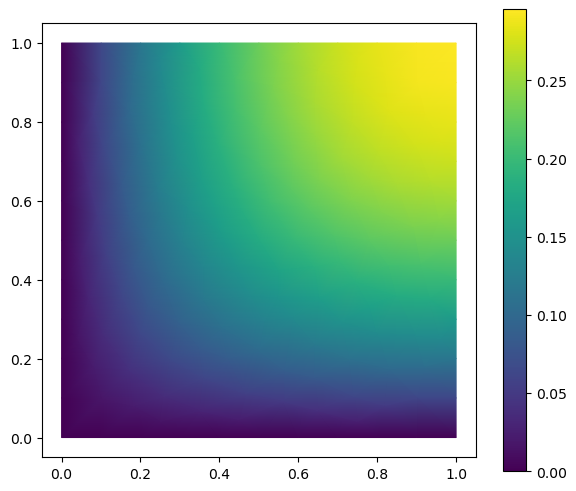

In [39]:
#-----------------
# Post-processing
#-----------------

fig, ax = plt.subplots(figsize=(7, 6))

tri = mtri.Triangulation(nodes[:, 0], nodes[:, 1], conn)

tpc = ax.tripcolor(
    tri,
    u_sol,
    shading='gouraud',
    edgecolors='none'
)

fig.colorbar(tpc, ax=ax)
ax.set_aspect('equal')

plt.show()